In [ ]:
import pandas as pd

In [2]:
# ------------------------------------------------------------------
# 1. utilitário: progress-bar para Joblib  --------------------------
# ------------------------------------------------------------------
from contextlib import contextmanager
from tqdm.auto import tqdm          # pip install tqdm
import joblib

@contextmanager
def tqdm_joblib(tqdm_object: tqdm):
    """
    Atualiza `tqdm_object` a cada lote concluído pela Joblib.
    """
    class TqdmBatchCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(self.batch_size)          # avança barra
            return super().__call__(*args, **kwargs)

    # troca a callback enquanto o 'with' estiver ativo
    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCallback
    try:
        yield tqdm_object
    finally:                           # garante restauração
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

/home/semcovici/facul/pesquisa/stellar-classification/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ----------------------------------------------------------
# 0. Dependências
# ----------------------------------------------------------
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier                 # pip install xgboost
from sklearn.model_selection import ParameterGrid

# ----------------------------------------------------------
# 1. Dados
# ----------------------------------------------------------
df_train = pd.read_csv("../data/raw/train.csv")
df_test  = pd.read_csv("../data/raw/test.csv")

# descarta colunas *_ID
cols_to_drop = [c for c in df_train.columns if "_ID" in c]
df_train = df_train.drop(columns=cols_to_drop)
df_test  = df_test.drop(columns=cols_to_drop)

y_train = df_train.pop("class")
y_test  = df_test.pop("class")

X_train = df_train.copy()
X_test  = df_test.copy()

# ----------------------------------------------------------
# 2. Encoding do alvo
# ----------------------------------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# ----------------------------------------------------------
# 3. Pipelines e grades de hiper-parâmetros
# ----------------------------------------------------------
pipelines = {

    "Dummy": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", DummyClassifier(random_state=42)),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(random_state=42)),
        ]
    ),
    "DecisionTree": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", DecisionTreeClassifier(random_state=42)),
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                num_class=len(le.classes_),
                # use_label_encoder=False,
                random_state=42,
            )),
        ]
    ),

}

param_grids = {
    "XGBoost": {
        "clf__n_estimators":  [200, 400],
        "clf__max_depth":     [3, 6, 9],
        "clf__learning_rate": [0.1, 0.01],
        "clf__subsample":     [0.8, 1.0],
        # "clf__use_label_encoder": False
    },
    "RandomForest": {
        "clf__n_estimators":     [200, 400],
        "clf__max_depth":        [None, 10, 20],
        "clf__min_samples_split":[2, 5],
    },
    "DecisionTree": {
        "clf__max_depth":     [None, 5, 10, 20],
        "clf__min_samples_leaf":[1, 2, 4],
    },
    "Dummy": {
        "clf__strategy": ["most_frequent", "stratified"],
    },
}

# ----------------------------------------------------------
# 4. Busca de hiper-parâmetros (+ validação cruzada)
# ----------------------------------------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

best_models = {}

for name, pipe in pipelines.items():
    print(f"\n\033[1m{name}\033[0m")
    param_grid = param_grids[name]
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1,             # → paraleliza *e* atualiza a barra
        verbose=0              # não precisamos do `verbose` textual
    )

    # total = nº de candidatos × nº de folds
    total_fits = len(ParameterGrid(param_grid)) * cv.get_n_splits(
        X_train, y_train_enc
    )

    print(f"\n🔍 Buscando hiperparâmetros para {name} …")
    with tqdm_joblib(tqdm(total=total_fits, desc=f"{name} Grid")):
        gs.fit(X_train, y_train_enc)

    best_models[name] = gs.best_estimator_

    print(f"Melhores parâmetros  : {gs.best_params_}")
    print(f"F1-score médio (CV)  : {gs.best_score_:.4f}")

# ----------------------------------------------------------
# 5. Avaliação no conjunto de teste
# ----------------------------------------------------------
metric_rows = []
for name, model in best_models.items():
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test_enc, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_enc, y_pred, average="weighted", zero_division=0
    )

    metric_rows.append(
        {
            "Modelo":       name,
            "Accuracy":     acc,
            "Precision":    prec,
            "Recall":       rec,
            "F1-score":     f1,
        }
    )

df_metrics = (
    pd.DataFrame(metric_rows)
      .set_index("Modelo")
      .round(4)
      .sort_values("F1-score", ascending=False)
)

print("\n===========  Desempenho no Teste  ===========")
print(df_metrics)



Dummy

🔍 Buscando hiperparâmetros para Dummy …


Dummy Grid: 100%|██████████| 6/6 [00:01<00:00,  3.81it/s]


Melhores parâmetros  : {'clf__strategy': 'most_frequent'}
F1-score médio (CV)  : 0.4432

RandomForest

🔍 Buscando hiperparâmetros para RandomForest …


RandomForest Grid: 100%|██████████| 36/36 [07:43<00:00, 12.86s/it]


Melhores parâmetros  : {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}
F1-score médio (CV)  : 0.9786

DecisionTree

🔍 Buscando hiperparâmetros para DecisionTree …


DecisionTree Grid: 100%|██████████| 36/36 [00:07<00:00,  4.88it/s]


Melhores parâmetros  : {'clf__max_depth': 10, 'clf__min_samples_leaf': 4}
F1-score médio (CV)  : 0.9733

XGBoost

🔍 Buscando hiperparâmetros para XGBoost …


XGBoost Grid: 100%|██████████| 72/72 [03:03<00:00,  2.55s/it]


Melhores parâmetros  : {'clf__learning_rate': 0.1, 'clf__max_depth': 9, 'clf__n_estimators': 200, 'clf__subsample': 0.8}
F1-score médio (CV)  : 0.9766

===========  Desempenho no Teste  ===========
              Accuracy  Precision  Recall  F1-score
Modelo                                             
RandomForest    0.9783     0.9782  0.9783    0.9782
XGBoost         0.9768     0.9766  0.9768    0.9766
DecisionTree    0.9736     0.9734  0.9736    0.9734
Dummy           0.5944     0.3534  0.5944    0.4433


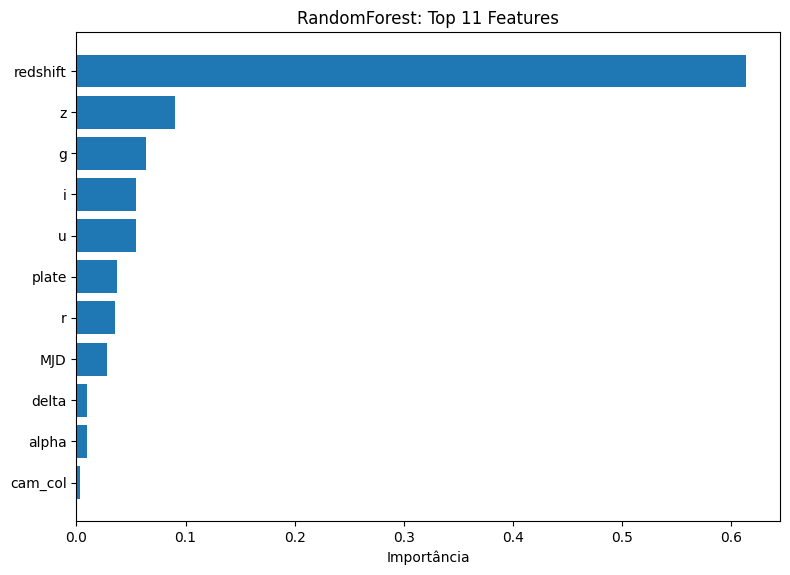

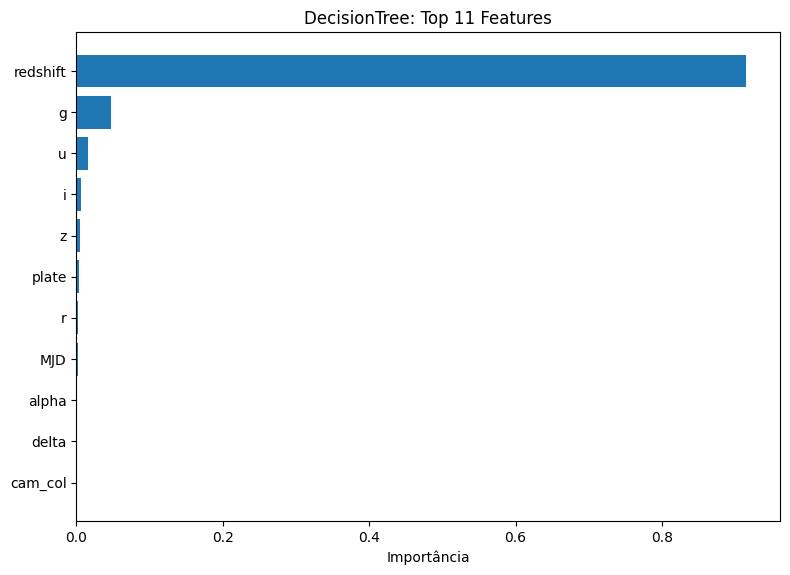

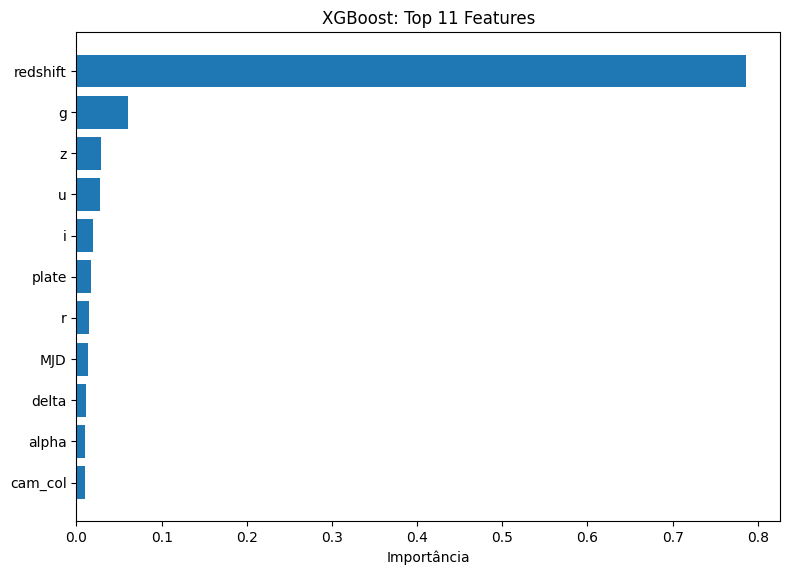

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_importance(pipeline, model_name, feature_names, top_n=20):
    """
    Plota importâncias de atributo do estimador em `pipeline.named_steps["clf"]`.
    Desenha no máximo `top_n`, mas nunca mais que o nº real de colunas.
    """
    clf = pipeline.named_steps["clf"]

    # Alguns estimadores podem não expor a propriedade (ex.: Dummy) ─ pulemos
    if not hasattr(clf, "feature_importances_"):
        print(f"{model_name} não possui 'feature_importances_'; ignorando.")
        return

    importances = clf.feature_importances_
    n_features = importances.size

    # --- ajusta o topo ao nº de colunas ---------------------------
    n = min(top_n, n_features)
    idx_sorted = np.argsort(importances)[::-1]
    idx_top    = idx_sorted[:n]

    # --- figura única, sem subplots  ------------------------------
    plt.figure(figsize=(8, 0.35 * n + 2))
    plt.barh(range(n), importances[idx_top][::-1])
    plt.yticks(range(n), feature_names[idx_top][::-1])
    plt.xlabel("Importância")
    plt.title(f"{model_name}: Top {n} Features")
    plt.tight_layout()
    plt.show()


feature_names = X_train.columns.to_numpy()

for name, model in best_models.items():
    if name == "Dummy":          # o Dummy não tem importâncias
        continue
    plot_feature_importance(
        pipeline=model,
        model_name=name,
        feature_names=feature_names,
        top_n=20                 # será reduzido se houver <20 colunas
    )
